In [13]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import load_img, img_to_array

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint

In [14]:
train_dir = "severity_split/train"
val_dir = "severity_split/val"
test_dir = "severity_split/test"

img_size = (224, 224)
batch_size = 32

In [15]:
train_gen = ImageDataGenerator(rescale=1./255)
val_gen = ImageDataGenerator(rescale=1./255)
test_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

val_data = val_gen.flow_from_directory(
    val_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

test_data = test_gen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 4267 images belonging to 3 classes.
Found 1220 images belonging to 3 classes.
Found 611 images belonging to 3 classes.


In [16]:
print("Class Mapping:", train_data.class_indices)

Class Mapping: {'high': 0, 'low': 1, 'medium': 2}


In [17]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze base layers
for layer in base_model.layers:
    layer.trainable = False

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dense(3, activation='softmax')  # 3 classes
])

In [18]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [19]:
checkpoint = ModelCheckpoint(
    "severity_model.keras",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

In [20]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=[checkpoint]
)

Epoch 1/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step - accuracy: 0.6922 - loss: 0.7710
Epoch 1: val_accuracy improved from -inf to 0.98033, saving model to severity_model.keras
134/134 ━━━━━━━━━━━━━━━━━━━━ 46s 332ms/step - accuracy: 0.6933 - loss: 0.7690 - val_accuracy: 0.9803 - val_loss: 0.1952
Epoch 2/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step - accuracy: 0.9954 - loss: 0.1402
Epoch 2: val_accuracy improved from 0.98033 to 0.99754, saving model to severity_model.keras
134/134 ━━━━━━━━━━━━━━━━━━━━ 45s 339ms/step - accuracy: 0.9954 - loss: 0.1400 - val_accuracy: 0.9975 - val_loss: 0.0686
Epoch 3/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 271ms/step - accuracy: 0.9997 - loss: 0.0538
Epoch 3: val_accuracy improved from 0.99754 to 1.00000, saving model to severity_model.keras
134/134 ━━━━━━━━━━━━━━━━━━━━ 47s 347ms/step - accuracy: 0.9997 - loss: 0.0537 - val_accuracy: 1.0000 - val_loss: 0.0348
Epoch 4/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step - accuracy: 1.0000 - loss: 0.0270
Epoch 4: val

In [21]:
test_loss, test_acc = model.evaluate(test_data)
print("Test Accuracy:", test_acc)

20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 232ms/step - accuracy: 1.0000 - loss: 0.0031
Test Accuracy: 1.0


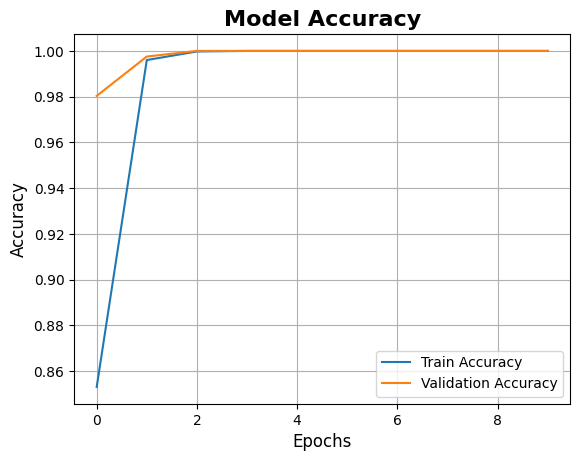

In [22]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Model Accuracy", fontsize=16, fontweight='bold')
plt.xlabel("Epochs", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)

plt.legend()
plt.grid(True)

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Actual: medium
Predicted: medium


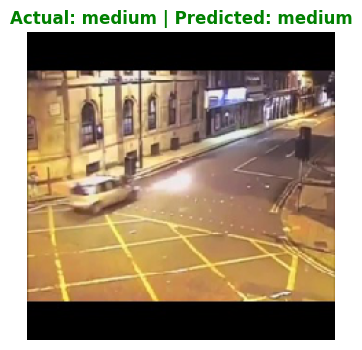

In [26]:
labels = ['high', 'low', 'medium']

folder = "severity_split/test/medium"
img_path = folder + "/" + random.choice(os.listdir(folder))

# Load image
img = load_img(img_path, target_size=(224,224))
img_array = img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Prediction
pred = model.predict(img_array)
predicted_label = labels[np.argmax(pred)]
actual_label = folder.split("/")[-1]

# Print results
print("Actual:", actual_label)
print("Predicted:", predicted_label)

# Show smaller image
import matplotlib.pyplot as plt

plt.figure(figsize=(4,4))  # 👈 smaller size (try 3,3 or 5,5 also)
plt.imshow(img)
plt.axis('off')

color = "green" if actual_label == predicted_label else "red"

plt.title(f"Actual: {actual_label} | Predicted: {predicted_label}",
          fontsize=12, fontweight='bold', color=color)

plt.show()

In [29]:
import os

for cls in ['high', 'low', 'medium']:
    path = f"severity_split/train/{cls}"
    print(cls, ":", len(os.listdir(path)))

high : 1496
low : 1311
medium : 1460


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


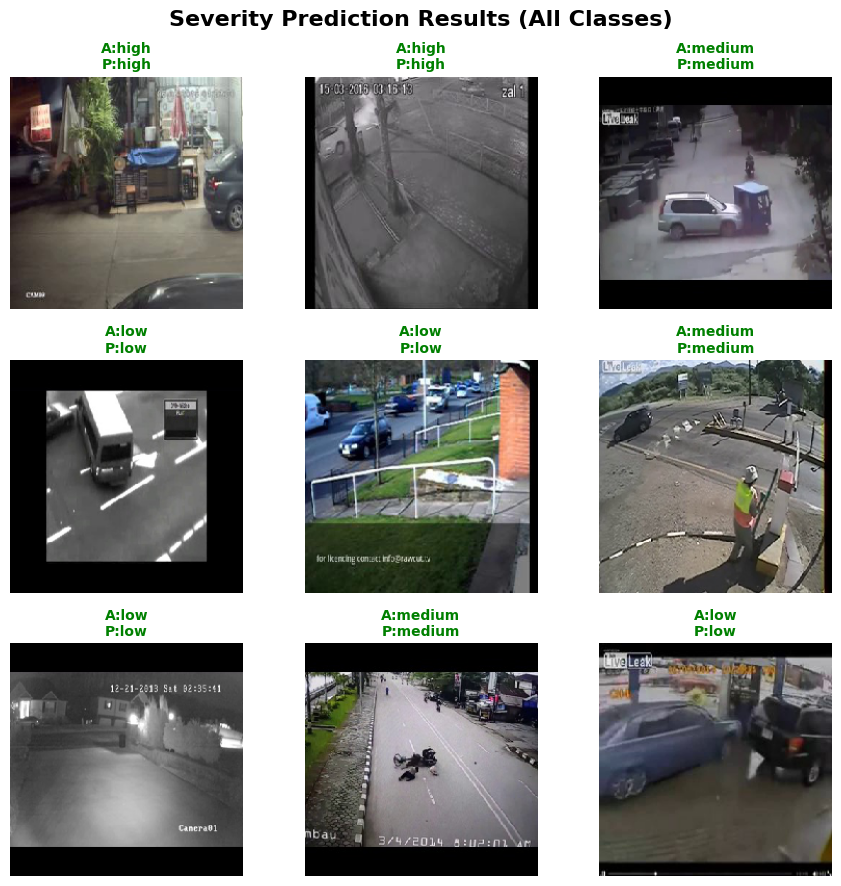

In [31]:
labels = ['high', 'low', 'medium']

import matplotlib.pyplot as plt
import random
import os

folders = [
    "severity_split/test/high",
    "severity_split/test/low",
    "severity_split/test/medium"
]

rows = 3
cols = 3

plt.figure(figsize=(cols*3, rows*3))

for i in range(rows * cols):

    folder = random.choice(folders)

    img_path = folder + "/" + random.choice(os.listdir(folder))

    img = load_img(img_path, target_size=(224,224))
    img_array = img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    pred = model.predict(img_array)
    predicted_label = labels[np.argmax(pred)]
    
    # ✅ Fix label extraction
    actual_label = folder.split("/")[-1]

    plt.subplot(rows, cols, i+1)
    plt.imshow(img)
    plt.axis('off')

    color = "green" if actual_label == predicted_label else "red"

    plt.title(f"A:{actual_label}\nP:{predicted_label}",
              fontsize=10, fontweight='bold', color=color)

# ✅ Add main heading
plt.suptitle("Severity Prediction Results (All Classes)",
             fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

In [32]:
from sklearn.metrics import classification_report, confusion_matrix

predictions = model.predict(test_data)
y_pred = np.argmax(predictions, axis=1)

print(confusion_matrix(test_data.classes, y_pred))
print(classification_report(test_data.classes, y_pred))

20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 258ms/step
[[214   0   0]
 [  0 188   0]
 [  0   0 209]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       214
           1       1.00      1.00      1.00       188
           2       1.00      1.00      1.00       209

    accuracy                           1.00       611
   macro avg       1.00      1.00      1.00       611
weighted avg       1.00      1.00      1.00       611



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


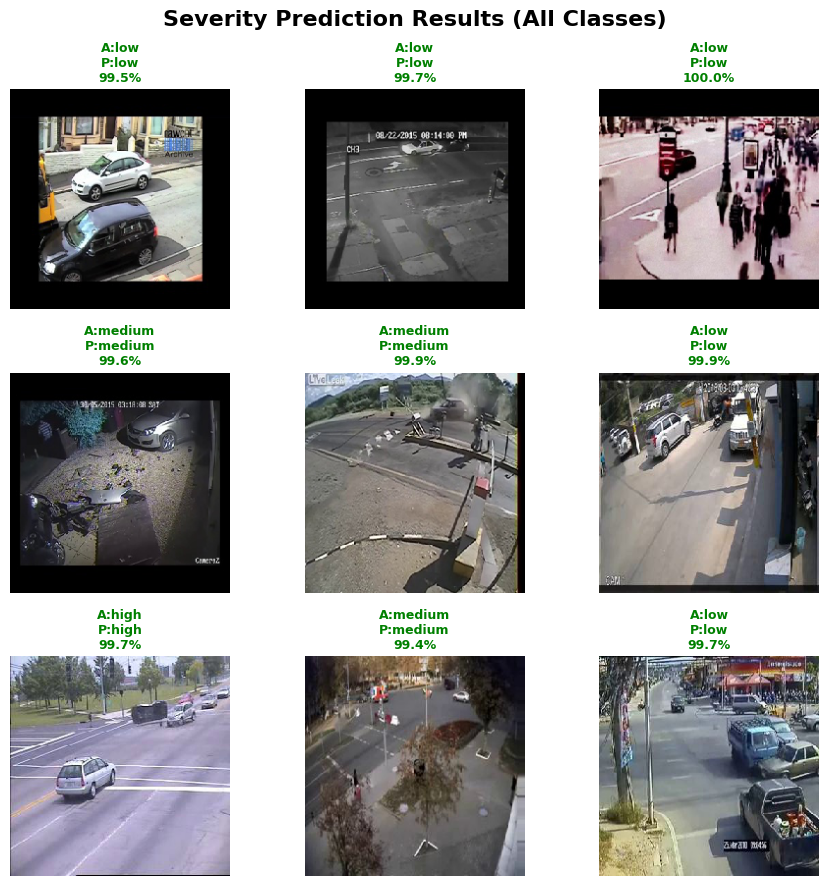

In [34]:
labels = ['high', 'low', 'medium']

import matplotlib.pyplot as plt
import random
import os

folders = [
    "severity_split/test/high",
    "severity_split/test/low",
    "severity_split/test/medium"
]

rows = 3
cols = 3

plt.figure(figsize=(cols*3, rows*3))

for i in range(rows * cols):

    folder = random.choice(folders)

    img_path = folder + "/" + random.choice(os.listdir(folder))

    img = load_img(img_path, target_size=(224,224))
    img_array = img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    pred = model.predict(img_array)

    predicted_label = labels[np.argmax(pred)]
    actual_label = folder.split("/")[-1]

    # ✅ Confidence score
    confidence = np.max(pred) * 100

    plt.subplot(rows, cols, i+1)
    plt.imshow(img)
    plt.axis('off')

    color = "green" if actual_label == predicted_label else "red"

    plt.title(
        f"A:{actual_label}\nP:{predicted_label}\n{confidence:.1f}%",
        fontsize=9,
        fontweight='bold',
        color=color
    )

# Main heading
plt.suptitle(
    "Severity Prediction Results (All Classes)",
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout()
plt.show()